<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
survived         0
pclass           0
sex              0
age            17

C:\Users\anumi\AppData\Local\Temp\ipykernel_30580\3606015781.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\anumi\AppData\Local\Temp\ipykernel_30580\3606015781.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('class')['survived'].mean())
C:\Users\anumi\

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64
class     First    Second     Third
sex                                
0      0.368852  0.157407  0.135447
1      0.968085  0.921053  0.500000


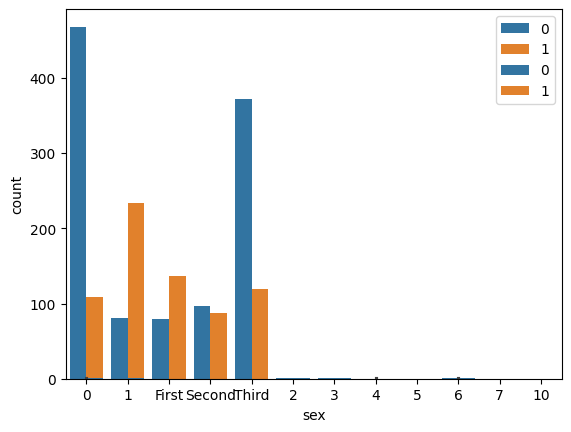

In [ ]:
# Task 1: Titanic Dataset Survival Analysis

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
df = sns.load_dataset("titanic")

# 2. Check data types, missing values, shape
print(df.info())
print(df.isnull().sum())

# 3. Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)
df.drop(columns=['deck'], inplace=True)  # drop cabin/deck

# 4. Encode categorical features
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['embarked'] = df['embarked'].map({'S':0, 'C':1, 'Q':2})

# 5. Survival vs gender/class/age group
sns.countplot(x='sex', hue='survived', data=df)
plt.savefig("charts/survival_vs_gender.png")

sns.countplot(x='class', hue='survived', data=df)
plt.savefig("charts/survival_vs_class.png")

# 6. Family size effect
df['family_size'] = df['sibsp'] + df['parch']
sns.barplot(x='family_size', y='survived', data=df)
plt.savefig("charts/survival_vs_family.png")

# 7. Groupby insights
print(df.groupby('class')['survived'].mean())
print(df.pivot_table(index='sex', columns='class', values='survived'))

# 8. Export cleaned dataset
df.to_csv("cleaned_titanic.csv", index=False)


## Conclusions
- Females had a significantly higher survival rate than males.
- Passengers in 1st class survived more than those in 2nd and 3rd class.
- Younger passengers had slightly better survival chances.
- Smaller families tended to survive more often than very large families.
- Fare and class were strong indicators of survival probability.


